In [55]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

HERE = Path().resolve()
PROJECT_ROOT = next(p for p in [HERE, *HERE.parents] if (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT)) 

from src.io.obd_loader import load_obd_csv, require_columns
from src.io.timebase import add_elapsed_time
from src.physics.kinematics import add_speed_ms, add_acceleration
from src.physics.longitudinal import VehicleParams, add_longitudinal_forces
from src.physics.power_energy import add_power_terms, add_energy_terms
from src.common.units import convert_mdot_to_kgs

In [56]:
df = load_obd_csv(PROJECT_ROOT/"data/KIT/2017-07-05_Seat_Leon_RT_S_Stau.csv")
require_columns(df, ["time", "speed_kmh", "engine_rpm"])

df = add_elapsed_time(df)
df = add_speed_ms(df)
df = add_acceleration(df)

params = VehicleParams(
    mass_kg=1300, Cd=0.3, area_m2=2.2, crr=0.012,
    tyre_radius_m=0.318, rho_air=1.17
)

df = add_longitudinal_forces(df, params, grade_rad=0.0)
df = add_power_terms(df)
df = add_energy_terms(df)
df = convert_mdot_to_kgs(df)

print(df)

               time  Engine Coolant Temperature [Â°C]  \
0      07:16:30.444                                31   
1      07:16:30.535                                31   
2      07:16:30.625                                31   
3      07:16:30.716                                31   
4      07:16:30.814                                31   
...             ...                               ...   
46344  08:22:15.439                                91   
46345  08:22:15.524                                91   
46346  08:22:15.615                                91   
46347  08:22:15.704                                91   
46348  08:22:15.794                                91   

       Intake Manifold Absolute Pressure [kPa]  engine_rpm  speed_kmh  \
0                                          NaN         NaN        NaN   
1                                         96.0         NaN        NaN   
2                                         96.0         0.0        NaN   
3                      

In [43]:
AFR = 14.7
LHV = 43e6
df.columns


#df["Pfuel"]  = df["mdot_fuel"]  / LHV


Index(['time', 'Engine Coolant Temperature [Â°C]',
       'Intake Manifold Absolute Pressure [kPa]', 'engine_rpm', 'speed_kmh',
       'Intake Air Temperature [Â°C]',
       'Air Flow Rate from Mass Flow Sensor [g/s]',
       'Absolute Throttle Position [%]', 'Ambient Air Temperature [Â°C]',
       'Accelerator Pedal Position D [%]', 'Accelerator Pedal Position E [%]',
       'elapsed_time_s', 'speed_ms', 'accel_ms2', 'F_aero_N', 'F_roll_N',
       'F_slope_N', 'F_inertia_N', 'F_trac_N', 'P_aero_W', 'P_roll_W',
       'P_inertia_W', 'P_wheel_W', 'P_drive_W', 'P_brake_W', 'E_aero_J',
       'E_roll_J', 'E_inertia_J', 'E_drive_J', 'E_brake_J', 'E_aero_kJ',
       'E_roll_kJ', 'E_inertia_kJ', 'E_drive_kJ', 'E_brake_kJ'],
      dtype='object')

In [44]:
df["Air Flow Rate from Mass Flow Sensor [kg/s]"] = df["Air Flow Rate from Mass Flow Sensor [g/s]"] / 100 
df["mdot_fuel"] = df["Air Flow Rate from Mass Flow Sensor [kg/s]"]  / AFR

df["mdot_fuel"].head(100)

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
        ...   
95    0.000619
96    0.000619
97    0.000619
98    0.000619
99    0.000619
Name: mdot_fuel, Length: 100, dtype: float64

In [45]:
df.columns

Index(['time', 'Engine Coolant Temperature [Â°C]',
       'Intake Manifold Absolute Pressure [kPa]', 'engine_rpm', 'speed_kmh',
       'Intake Air Temperature [Â°C]',
       'Air Flow Rate from Mass Flow Sensor [g/s]',
       'Absolute Throttle Position [%]', 'Ambient Air Temperature [Â°C]',
       'Accelerator Pedal Position D [%]', 'Accelerator Pedal Position E [%]',
       'elapsed_time_s', 'speed_ms', 'accel_ms2', 'F_aero_N', 'F_roll_N',
       'F_slope_N', 'F_inertia_N', 'F_trac_N', 'P_aero_W', 'P_roll_W',
       'P_inertia_W', 'P_wheel_W', 'P_drive_W', 'P_brake_W', 'E_aero_J',
       'E_roll_J', 'E_inertia_J', 'E_drive_J', 'E_brake_J', 'E_aero_kJ',
       'E_roll_kJ', 'E_inertia_kJ', 'E_drive_kJ', 'E_brake_kJ',
       'Air Flow Rate from Mass Flow Sensor [kg/s]', 'mdot_fuel'],
      dtype='object')

In [46]:
df["Pfuel"]  = df["mdot_fuel"] * LHV

In [57]:
df["elapsed_time_s"]

0           0.000
1           0.091
2           0.181
3           0.272
4           0.370
           ...   
46344    3944.995
46345    3945.080
46346    3945.171
46347    3945.260
46348    3945.350
Name: elapsed_time_s, Length: 46349, dtype: float64

In [48]:

df["chemical_efficiency"] = df["P_drive_W"] / df["Pfuel"]
#df = add_elapsed_time(df)



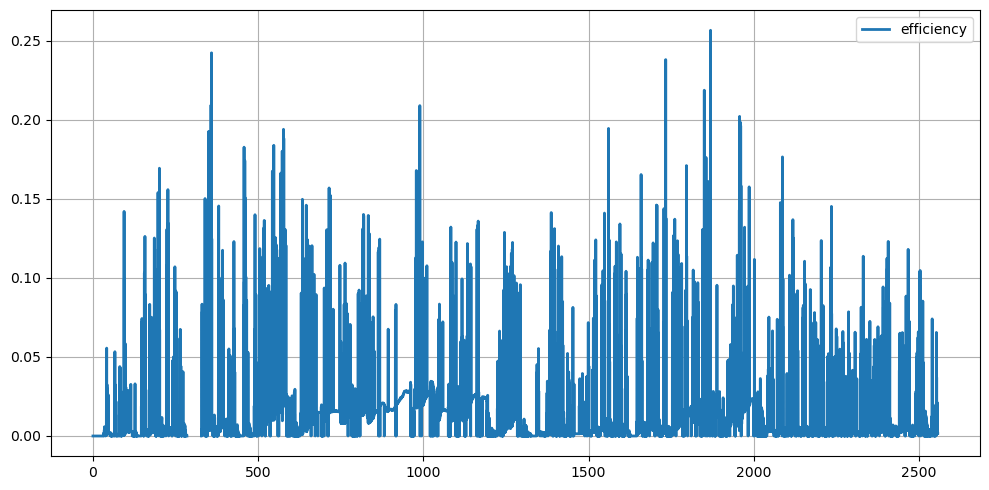

In [54]:
sub = df.iloc[:30000].copy()

plt.figure(figsize=(10,5))
plt.plot(sub["elapsed_time_s"], sub["chemical_efficiency"], label="efficiency", linewidth=2)

plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [24]:
'''

filter out  a <= 0.1 so that only df that is within this range is left

df[ftr predicted] = df[fi] + df[fd] + df[frr]

'''

'\n\nfilter out  a <= 0.1 so that only df that is within this range is left\n\ndf[ftr predicted] = df[fi] + df[fd] + df[frr]\n\n'

In [ ]:
result = (df['A'] > df['B']).any()

print(result) 